# 房产估值 DCF 现金流贴现模型

**方法：** 实际值（Real Terms）框架下的 DCF 模型，用于自住房产估值

**模型结构：**
1. **公允价值分析** — 居住使用价值（不考虑贷款结构）
2. **NPV 决策模型** — 买房 vs 租房+投资的财务对比
3. **敏感性分析** — 关键参数变动对结果的影响

---
## 1. 输入参数

所有参数集中在此，修改后从头运行即可刷新全部输出。

In [90]:
# ============================================================
# 购房方案参数 — 根据你的实际购房条件修改
# ============================================================

house_price = 1_500_000            # 总房价（元），如 150 万
down_payment_ratio = 0.20           # 首付比例，如 20% → 0.20
loan_rate = 0.026                   # 贷款利率（年化），如 2.6% → 0.026
loan_term_years = 30                # 贷款年限

# ============================================================
# 估值假设 — 根据你对未来的预期修改
# ============================================================

monthly_rent = 3_000                # 同户型月租金（元），即你每月省下的钱
annual_holding_cost = 2_000         # 年持有成本（元），物业费 + 维修 + 保险等
real_growth_rate = 0.015            # 租金/持有成本的实际年增长率，如 1.5% → 0.015
inflation = 0.01                    # 通胀率，用于把固定月供转为实际值，如 1% → 0.01
discount_rate = 0.04                # 实际折现率，即你的资金机会成本，如 4% → 0.04
terminal_value = 650_000            # 期末残值（元），按今天购买力估算，不折现
holding_years = 30                  # 持有期（年），一般等于贷款年限

# ============================================================
# 税费参数 — 买房/卖房一次性费用
# ============================================================

deed_tax_rate = 0.01                # 契税比例（首套 ≤ 140m² 为 1%）
agency_fee_rate = 0.01              # 中介费比例（如通过中介，无中介则设为 0）
other_purchase_fees = 0.00          # 其他杂费（维修基金 50-100元/m²、登记费等）
vat_rate = 0.00                     # 增值税率（满二免征，默认 0%）
iit_rate = 0.00                     # 个人所得税率（满五唯一免征，默认 0%）

# ============================================================
# 派生参数 — 自动计算，无需修改
# ============================================================

down_payment = house_price * down_payment_ratio          # 首付金额
loan_amount = house_price - down_payment                 # 贷款本金
annual_rent = monthly_rent * 12                          # 年租金（省下的）

purchase_fees = house_price * (deed_tax_rate + agency_fee_rate) + other_purchase_fees  # 买房一次性总费用
print(f"首付: {down_payment:,.0f} 元")
print(f"贷款金额: {loan_amount:,.0f} 元")

首付: 300,000 元
贷款金额: 1,200,000 元


---
## 2. 公允价值分析

**不涉及贷款结构**，计算这套房的居住使用价值。

公允价值 = Σ(省租金 - 持有成本) / (1+折现率)^t + 期末残值（不折现）

In [91]:
# ============================================================
# 公允价值分析 — 不涉及贷款，只看居住价值
# 公式：公允价值 = Σ(省租金-持有成本)/(1+折现率)^t + 期末残值
# ============================================================

fair_value_cf = []    # 每年净省下的钱（当年价格）
fair_value_pv = []    # 每年净省下的钱折现到今天

for t in range(1, holding_years + 1):                   # t = 第 1 年到第 30 年
    # 第 t 年省下的租金，按实际增长率逐年递增
    rent = annual_rent * (1 + real_growth_rate)**(t - 1)
    # 第 t 年的持有成本，同样按实际增长率递增
    cost = annual_holding_cost * (1 + real_growth_rate)**(t - 1)
    # 第 t 年净省下的钱
    cf = rent - cost
    # 折现到今天：除以 (1 + 折现率)^t
    pv = cf / (1 + discount_rate)**t

    fair_value_cf.append(cf)
    fair_value_pv.append(pv)

# 公允价值 = 30 年折现值的总和 + 期末残值（不折现）
fair_value = sum(fair_value_pv) + terminal_value

# ---------- 输出结果 ----------

print("=" * 55)
print("  公允价值分析")
print("=" * 55)
print(f"\n省租金现值总计: {sum(fair_value_pv):>12,.0f} 元")
print(f"期末残值（不折现）: {terminal_value:>12,.0f} 元")
print(f"\n{'─' * 45}")
print(f"居住公允价值: {fair_value:>12,.0f} 元")
print(f"当前售价: {house_price:>12,.0f} 元")
print(f"价差: {house_price - fair_value:>12,.0f} 元")
print(f"{'─' * 45}")

premium_ratio = (house_price - fair_value) / house_price * 100
if fair_value > house_price:
    print(f"\n→ 公允价值高于售价，居住价值上值得购买。")
else:
    print(f"\n→ 公允价值低于售价（{-premium_ratio:.1f}%），")
    print(f"  溢价部分反映的是地段、供需等市场因素。")

  公允价值分析

省租金现值总计:      704,580 元
期末残值（不折现）:      650,000 元

─────────────────────────────────────────────
居住公允价值:    1,354,580 元
当前售价:    1,500,000 元
价差:      145,420 元
─────────────────────────────────────────────

→ 公允价值低于售价（-9.7%），
  溢价部分反映的是地段、供需等市场因素。


---
## 3. 月供计算

等额本息方式，月供固定不变。

In [92]:
# ============================================================
# 月供计算 — 等额本息，每月还款额固定不变
# ============================================================

import math

monthly_rate = loan_rate / 12                # 月利率 = 年利率 ÷ 12
n_months = loan_term_years * 12              # 总期数 = 年限 × 12

# 等额本息公式：月供 = 本金 × 月利率 × (1+月利率)^期数 ÷ ((1+月利率)^期数 - 1)
monthly_payment = loan_amount * monthly_rate * (1 + monthly_rate)**n_months / \
                  ((1 + monthly_rate)**n_months - 1)
annual_payment = monthly_payment * 12                     # 年供金额
total_repayment = monthly_payment * n_months              # 30 年总还款额
total_interest = total_repayment - loan_amount            # 其中利息总额

print(f"月供（等额本息）: {monthly_payment:,.0f} 元/月")
print(f"年供: {annual_payment:,.0f} 元/年")
print(f"30年总还款: {total_repayment:,.0f} 元")
print(f"其中利息: {total_interest:,.0f} 元")

月供（等额本息）: 4,804 元/月
年供: 57,649 元/年
30年总还款: 1,729,468 元
其中利息: 529,468 元


---
## 4. 年度现金流表

逐年计算实际值（Real Terms）现金流。

In [93]:
# ============================================================
# 年度现金流表 — 逐年计算实际值（含首付、月供、终值）
# ============================================================

years = list(range(holding_years + 1))        # [0, 1, 2, ..., 30]

rent_saved_real = []     # 省租金（实际值，按今天购买力）
holding_costs_real = []  # 持有成本（实际值）
loan_payment_real = []   # 月供（实际值，用通胀率把固定名义月供折减）
net_cf = []              # 每年净现金流

for t in years:
    if t == 0:
        # 第 0 年（现在）：只有首付支出，其他项目为 0
        rent_saved_real.append(0)
        holding_costs_real.append(0)
        loan_payment_real.append(0)
        net_cf.append(-down_payment - purchase_fees)          # 负号表示现金流出
    else:
        # 第 t 年省下的租金（实际值），每年涨 1.5%
        rent = annual_rent * (1 + real_growth_rate)**(t - 1)
        # 第 t 年持有成本（实际值），同样每年涨 1.5%
        cost = annual_holding_cost * (1 + real_growth_rate)**(t - 1)
        # 月供是固定名义值，用通胀率折成实际值：通胀越高，未来月供实际负担越轻
        loan_real = annual_payment / (1 + inflation)**(t - 1)

        rent_saved_real.append(rent)
        holding_costs_real.append(cost)
        loan_payment_real.append(loan_real)
        net_cf.append(rent - cost - loan_real)

# 第 30 年额外加上期末残值（卖出房子的钱）
net_cf[holding_years] += terminal_value

# ---------- 输出现金流明细（每 5 年 + 第 30 年） ----------

print(f"{'年份':>4} | {'省租金(实)':>10} | {'持有成本(实)':>10} | {'月供(实)':>10} | {'净现金流':>10}")
print("-" * 60)
for i, t in enumerate(years):
    if t == 0:
        print(f"{t:>4} | {'---':>10} | {'---':>10} | {'---':>10} | {net_cf[i]:>10,.0f}")
    elif t % 5 == 0 or t == holding_years:
        print(f"{t:>4} | {rent_saved_real[i]:>10,.0f} | {holding_costs_real[i]:>10,.0f} | "
              f"{loan_payment_real[i]:>10,.0f} | {net_cf[i]:>10,.0f}")

# ---------- 30 年汇总统计 ----------

total_rent_saved = sum(rent_saved_real[1:])     # 30 年省租金总和（实际值）
total_holding = sum(holding_costs_real[1:])      # 30 年持有成本总和
total_loan_real = sum(loan_payment_real[1:])     # 30 年月供总和（实际值）
total_net = sum(net_cf)                          # 30 年净现金流总和

print("\n--- 30年汇总（实际值） ---")
print(f"省租金总计: {total_rent_saved:,.0f} 元")
print(f"持有成本总计: {total_holding:,.0f} 元")
print(f"月供总计（实际值）: {total_loan_real:,.0f} 元")
print(f"买房税费: {purchase_fees:,.0f} 元")
print(f"净现金流总计（含首付和终值）: {total_net:,.0f} 元")

  年份 |     省租金(实) |    持有成本(实) |      月供(实) |       净现金流
------------------------------------------------------------
   0 |        --- |        --- |        --- |   -330,000
   5 |     38,209 |      2,123 |     55,399 |    -19,313
  10 |     41,162 |      2,287 |     52,711 |    -13,835
  15 |     44,343 |      2,464 |     50,152 |     -8,273
  20 |     47,770 |      2,654 |     47,718 |     -2,602
  25 |     51,462 |      2,859 |     45,402 |      3,201
  30 |     55,439 |      3,080 |     43,199 |    659,161

--- 30年汇总（实际值） ---
省租金总计: 1,351,393 元
持有成本总计: 75,077 元
月供总计（实际值）: 1,502,664 元
买房税费: 30,000 元
净现金流总计（含首付和终值）: 93,651 元


---
## 5. NPV 决策模型

**买房 vs 租房+投资**，按实际值框架计算净现值。

NPV = -首付 + Σ(净现金流(t) / (1+折现率)^t) + 期末残值（不折现）

In [94]:
# ============================================================
# NPV 决策模型 — 买房 vs 租房+投资
# NPV = -首付 + Σ(净现金流/1.04^t) + 期末残值（不折现）
# NPV > 0  → 买房划算     NPV < 0  → 租房划算
# ============================================================

npv_cf_pv = []              # 每年折现后的净现金流
cumulative_npv = []         # 累积 NPV（逐年累加，可观察变化趋势）

# ---- t = 0（现在）：付首付 ----
npv = -down_payment - purchase_fees
cumulative_npv.append(npv)

# ---- t = 1 到 30：逐年计算净现金流并折现 ----

for t in range(1, holding_years + 1):
    # 第 t 年省下的租金（实际值）
    rent = annual_rent * (1 + real_growth_rate)**(t - 1)
    # 第 t 年持有成本（实际值）
    cost = annual_holding_cost * (1 + real_growth_rate)**(t - 1)
    # 第 t 年月供（实际值，通胀折减）
    loan_real = annual_payment / (1 + inflation)**(t - 1)
    # 当年的净现金流
    cf = rent - cost - loan_real
    # 按 4% 折现率折回今天
    pv = cf / (1 + discount_rate)**t

    npv_cf_pv.append(pv)
    npv += pv
    cumulative_npv.append(npv)

# 加上期末残值（不折现）
npv += terminal_value
cumulative_npv[-1] = npv      # 更新第 30 年的累积 NPV

# ---------- 输出结果 ----------

print("=" * 55)
print("  NPV 决策分析（买 vs 租）")
print("=" * 55)
print(f"\n首付现金流出: {down_payment:>12,.0f} 元")
print(f"买房税费: {purchase_fees:>12,.0f} 元")
print(f"年度现金流现值总和: {sum(npv_cf_pv):>12,.0f} 元")
print(f"期末残值（不折现）: {terminal_value:>12,.0f} 元")
print(f"\n{'─' * 45}")
print(f"净现值 (NPV): {npv:>12,.0f} 元")
print(f"{'─' * 45}")
if npv > 0:
    print(f"\n→ NPV > 0，买房比租房更划算。")
else:
    print(f"\n→ NPV < 0，租房并将资金用于投资（年化{discount_rate*100:.0f}%）更划算。")
    print(f"  但房子还提供居住体验、稳定性等非财务价值，需综合判断。")

  NPV 决策分析（买 vs 租）

首付现金流出:      300,000 元
买房税费:       30,000 元
年度现金流现值总和:     -186,421 元
期末残值（不折现）:      650,000 元

─────────────────────────────────────────────
净现值 (NPV):      133,579 元
─────────────────────────────────────────────

→ NPV > 0，买房比租房更划算。


---
## 6. 敏感性分析

观察折现率和租金增长率两个关键参数变化对 NPV 的影响。

In [95]:
# ============================================================
# 敏感性分析 — 看折现率和增长率变化对 NPV 的影响
# ============================================================

discount_rates = [0.03, 0.04, 0.05]      # 折现率：3%、4%、5%
growth_rates = [0.00, 0.015, 0.03]       # 增长率：0%、1.5%、3%

sensitivity_matrix = []                   # 存储结果，行=折现率，列=增长率

for dr in discount_rates:
    row = []
    for gr in growth_rates:
        # 对每组 (折现率, 增长率) 重新算一遍 NPV
        npv_val = -down_payment - purchase_fees
        for t in range(1, holding_years + 1):
            rent = annual_rent * (1 + gr)**(t - 1)
            cost = annual_holding_cost * (1 + gr)**(t - 1)
            loan_real = annual_payment / (1 + inflation)**(t - 1)
            cf = rent - cost - loan_real
            npv_val += cf / (1 + dr)**t
        npv_val += terminal_value
        row.append(npv_val)
    sensitivity_matrix.append(row)

# ---------- 输出敏感性矩阵 ----------

print("=" * 65)
print("  敏感性分析：NPV（元）")
print("=" * 65)
header = f"{'折现率':>8} | {'增长 0%':>12} | {'增长 1.5%':>12} | {'增长 3%':>12}"
print(header)
print("-" * 55)
for i, dr in enumerate(discount_rates):
    print(f"{dr*100:>6.0f}%  | {sensitivity_matrix[i][0]:>12,.0f} | {sensitivity_matrix[i][1]:>12,.0f} | {sensitivity_matrix[i][2]:>12,.0f}")
print("-" * 55)

  敏感性分析：NPV（元）
     折现率 |        增长 0% |      增长 1.5% |        增长 3%
-------------------------------------------------------
     3%  |      -16,763 |      123,827 |      307,113
     4%  |       16,929 |      133,579 |      284,540
     5%  |       45,470 |      142,907 |      268,063
-------------------------------------------------------


---
## 7. 盈亏平衡分析

在给定折现率和增长率的条件下，找到 NPV=0 时的房价。

In [96]:
# ============================================================
# 盈亏平衡分析 — 给定参数下，NPV=0 时的房价是多少？
# 房价越高 → 首付越高 + 月供越高 → NPV 越低
# 用二分法找到 NPV 刚好归零的房价
# ============================================================


def calculate_npv(price, dr, gr):
    """
    给定房价 price、折现率 dr、增长率 gr，计算 NPV。
    不修改全局参数，独立计算。
    """
    dp = price * down_payment_ratio                       # 按比例计算首付
    fees = price * (deed_tax_rate + agency_fee_rate) + other_purchase_fees  # 按比例计算税费
    la = price - dp                                       # 贷款本金
    mr = loan_rate / 12                                   # 月利率
    nm = loan_term_years * 12                             # 总期数
    mp = la * mr * (1 + mr)**nm / ((1 + mr)**nm - 1)     # 月供
    ap = mp * 12                                          # 年供

    npv_val = -dp - fees
    for t in range(1, holding_years + 1):
        rent = annual_rent * (1 + gr)**(t - 1)
        cost = annual_holding_cost * (1 + gr)**(t - 1)
        loan_real = ap / (1 + inflation)**(t - 1)
        cf = rent - cost - loan_real
        npv_val += cf / (1 + dr)**t
    npv_val += terminal_value
    return npv_val


def find_breakeven(dr, gr):
    """
    二分法找盈亏平衡房价。
    原理：NPV 随房价增加而递减（单调函数）。
    如果 NPV(mid) > 0 → 房价太低 → 提高下界
    如果 NPV(mid) < 0 → 房价太高 → 降低上界
    """
    lo, hi = 10_000, 10_000_000                # 搜索范围：1 万 ~ 1000 万
    for _ in range(50):                        # 迭代 50 次，精度足够
        mid = (lo + hi) / 2
        npv_mid = calculate_npv(mid, dr, gr)
        if npv_mid > 0:
            lo = mid                            # NPV > 0 → 房价太低，提高下界
        else:
            hi = mid                            # NPV < 0 → 房价太高，降低上界
    return (lo + hi) / 2                        # 返回中点作为近似解

# ---------- 基准场景（当前参数的盈亏平衡房价） ----------

print("=" * 60)
print("  盈亏平衡房价分析（NPV = 0）")
print("=" * 60)
print(f"\n基准参数：折现率 {discount_rate*100:.0f}%，增长率 {real_growth_rate*100:.1f}%")
print(f"参考：当前售价 = {house_price:,.0f} 元")

be_price = find_breakeven(discount_rate, real_growth_rate)
print(f"\n盈亏平衡房价: {be_price:>12,.0f} 元")
print(f"当前售价:      {house_price:>12,.0f} 元")

diff = house_price - be_price
if diff > 0:
    print(f"当前售价高出 {diff:>12,.0f} 元")
else:
    print(f"当前售价低于 {-diff:>12,.0f} 元")

# ---------- 多场景盈亏平衡（9 种组合） ----------

print("\n--- 多场景盈亏平衡 ---")
print(f"{'增长率':>8} | {'折现率3%':>12} | {'折现率4%':>12} | {'折现率5%':>12}")
print("-" * 50)
for gr in growth_rates:
    row_str = f"{gr*100:>6.1f}% |"
    for dr in discount_rates:
        be = find_breakeven(dr, gr)
        row_str += f" {be:>10,.0f}  |"
    print(row_str)

  盈亏平衡房价分析（NPV = 0）

基准参数：折现率 4%，增长率 1.5%
参考：当前售价 = 1,500,000 元

盈亏平衡房价:    1,664,102 元
当前售价:         1,500,000 元
当前售价低于      164,102 元

--- 多场景盈亏平衡 ---
     增长率 |        折现率3% |        折现率4% |        折现率5%
--------------------------------------------------
   0.0% |  1,481,139  |  1,520,797  |  1,560,509  |
   1.5% |  1,639,321  |  1,664,102  |  1,690,172  |
   3.0% |  1,845,542  |  1,849,558  |  1,856,722  |


---
## 8. 可视化

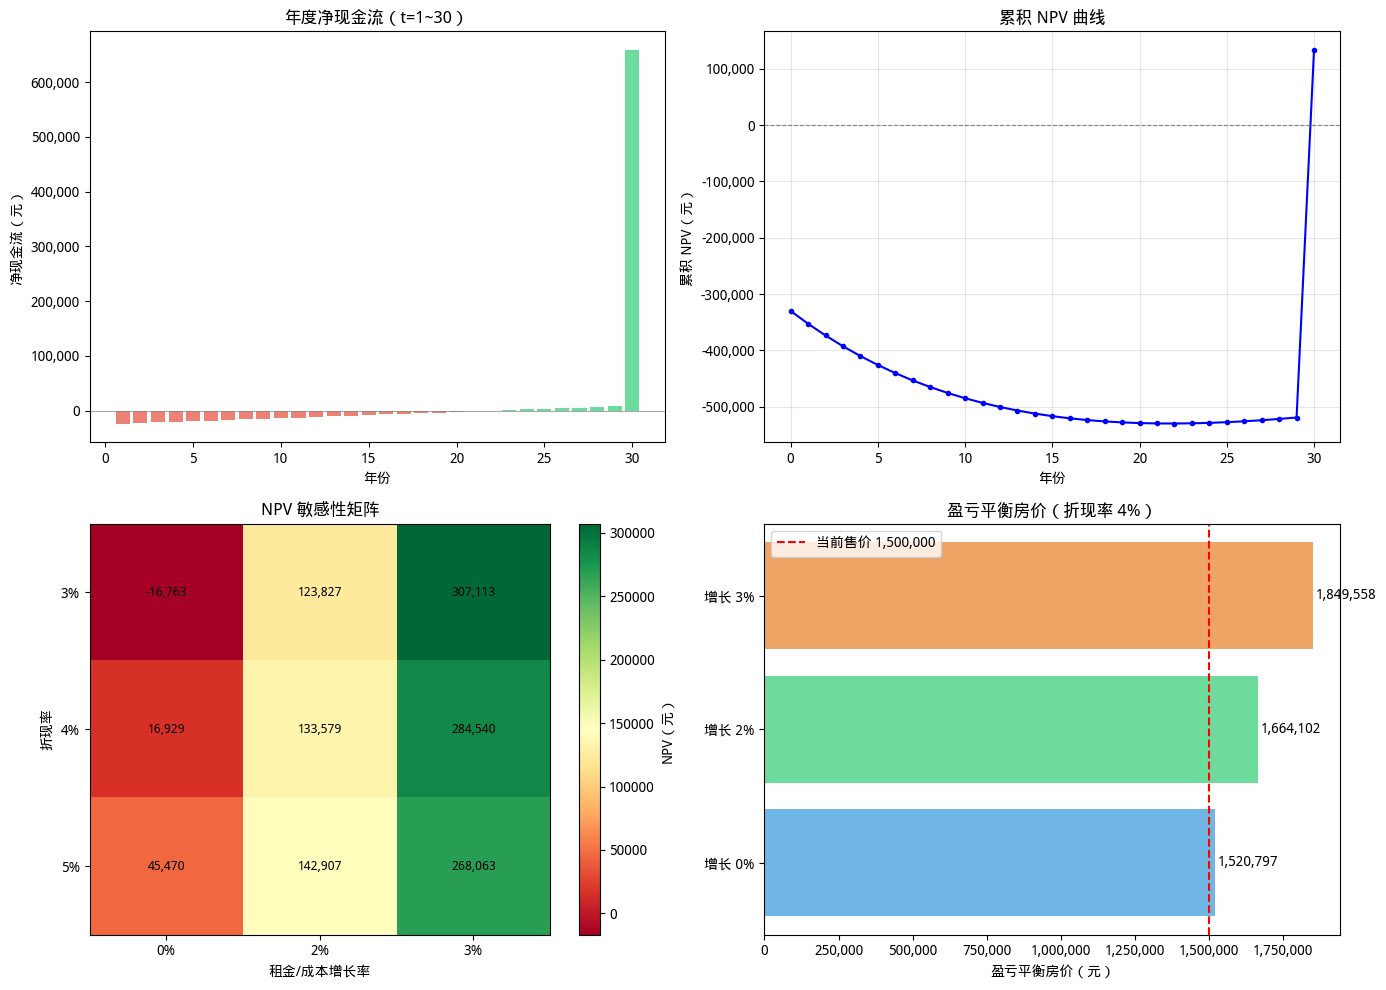

In [97]:
# ============================================================
# 可视化 — 四张图直观展示分析结果
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ---------- 中文字体设置 ----------

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC',
                                    'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ======== 图1: 年度净现金流柱状图 ========
ax1 = axes[0, 0]
plot_years = years[1:]
plot_cf = net_cf[1:]
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in plot_cf]
ax1.bar(plot_years, plot_cf, color=colors, alpha=0.7)
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax1.set_xlabel('年份')
ax1.set_ylabel('净现金流（元）')
ax1.set_title('年度净现金流（t=1~30）')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ======== 图2: 累积 NPV 曲线 ========
ax2 = axes[0, 1]
ax2.plot(years, cumulative_npv, 'b-o', markersize=3, linewidth=1.5)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('年份')
ax2.set_ylabel('累积 NPV（元）')
ax2.set_title('累积 NPV 曲线')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(True, alpha=0.3)

# ======== 图3: 敏感性热力图 ========
ax3 = axes[1, 0]
sensitivity_array = np.array(sensitivity_matrix)
im = ax3.imshow(sensitivity_array, cmap='RdYlGn', aspect='auto')
ax3.set_xticks(range(len(growth_rates)))
ax3.set_yticks(range(len(discount_rates)))
ax3.set_xticklabels([f'{g*100:.0f}%' for g in growth_rates])
ax3.set_yticklabels([f'{d*100:.0f}%' for d in discount_rates])
ax3.set_xlabel('租金/成本增长率')
ax3.set_ylabel('折现率')
ax3.set_title('NPV 敏感性矩阵')
for i in range(len(discount_rates)):
    for j in range(len(growth_rates)):
        val = sensitivity_array[i, j]
        ax3.text(j, i, f'{val:,.0f}', ha='center', va='center',
                color='black', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax3, label='NPV（元）')

# ======== 图4: 盈亏平衡对比 ========
ax4 = axes[1, 1]
be_prices = []
be_labels = []
for gr in growth_rates:
    be = find_breakeven(discount_rate, gr)
    be_prices.append(be)
    be_labels.append(f'增长 {gr*100:.0f}%')

bar_colors = ['#3498db', '#2ecc71', '#e67e22']
bars = ax4.barh(be_labels, be_prices, color=bar_colors, alpha=0.7)
ax4.axvline(x=house_price, color='red', linestyle='--', linewidth=1.5,
            label=f'当前售价 {house_price:,.0f}')
ax4.set_xlabel('盈亏平衡房价（元）')
ax4.set_title(f'盈亏平衡房价（折现率 {discount_rate*100:.0f}%）')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax4.legend()
for bar, price in zip(bars, be_prices):
    ax4.text(price + 10000, bar.get_y() + bar.get_height()/2,
             f'{price:,.0f}', va='center')

plt.tight_layout()
plt.show()

---
## 9. 生成估值报告

运行以下 Cell，可选输出 Markdown 报告和/或 PNG 图片报告。
通过 `report_format` 变量控制：`"markdown"`、`"image"` 或 `"both"`。
结果保存到 `reports/` 目录。


✓ Markdown 报告: reports/2026-06-08-估值报告.md


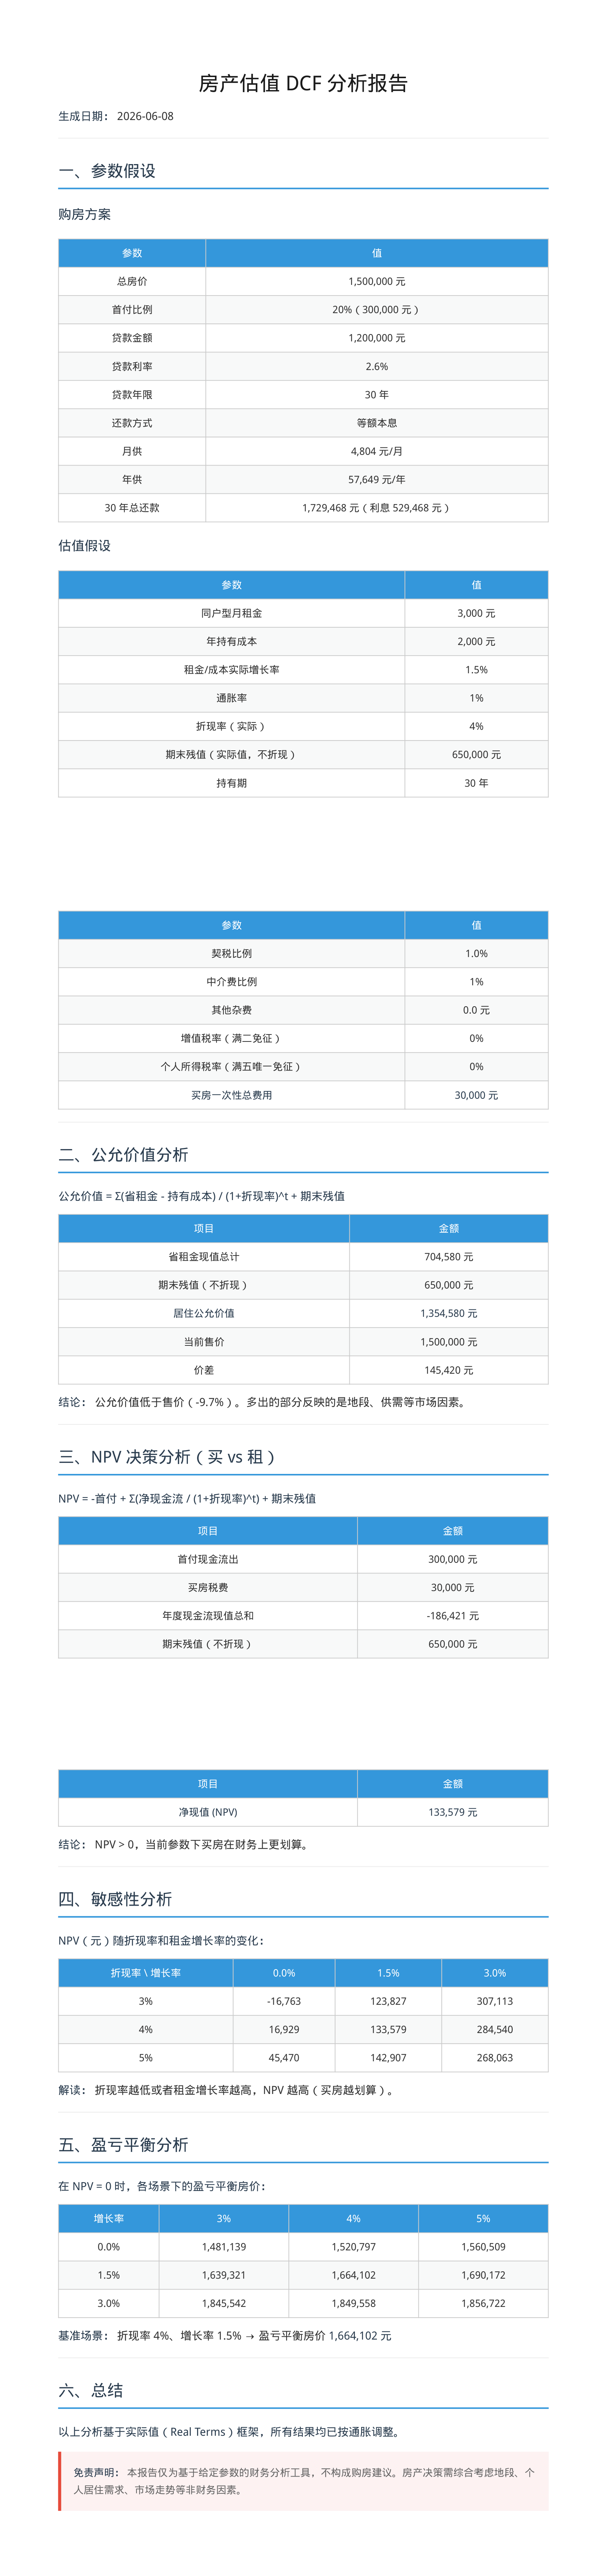

In [98]:
# ============================================================
# 9. 生成估值报告 — Markdown 和/或 PNG 图片输出
# ============================================================

# ----- 输出格式开关 -----
# report_format = "markdown"  输出 .md 文件
# report_format = "image"     输出 .png 图片
# report_format = "both"      同时输出 .md 和 .png
report_format = "both"

import datetime
import os
import markdown as md_lib
import weasyprint
import pymupdf
from IPython.display import display, Image

today = datetime.date.today().strftime("%Y-%m-%d")
report_dir = "reports"
os.makedirs(report_dir, exist_ok=True)

# ----- 收集数据 -----
fair_value_pv_sum = sum(fair_value_pv)
premium_ratio = (house_price - fair_value) / house_price * 100
npv_annual_pv_sum = sum(npv_cf_pv)

dr_labels = [f"{dr*100:.0f}%" for dr in discount_rates]
gr_labels = [f"{gr*100:.1f}%" for gr in growth_rates]

be_base = find_breakeven(discount_rate, real_growth_rate)
be_matrix = {}
for gr in growth_rates:
    for dr in discount_rates:
        be_matrix[(dr, gr)] = find_breakeven(dr, gr)

# ----- 构建报告内容 -----
report = f"""# 房产估值 DCF 分析报告

**生成日期：** {today}

---

## 一、参数假设

### 购房方案

| 参数 | 值 |
|---|---|
| 总房价 | {house_price:,.0f} 元 |
| 首付比例 | {down_payment_ratio*100:.0f}%（{down_payment:,.0f} 元） |
| 贷款金额 | {loan_amount:,.0f} 元 |
| 贷款利率 | {loan_rate*100:.1f}% |
| 贷款年限 | {loan_term_years} 年 |
| 还款方式 | 等额本息 |
| 月供 | {monthly_payment:,.0f} 元/月 |
| 年供 | {annual_payment:,.0f} 元/年 |
| 30 年总还款 | {total_repayment:,.0f} 元（利息 {total_interest:,.0f} 元）|

### 估值假设

| 参数 | 值 |
|---|---|
| 同户型月租金 | {monthly_rent:,} 元 |
| 年持有成本 | {annual_holding_cost:,} 元 |
| 租金/成本实际增长率 | {real_growth_rate*100:.1f}% |
| 通胀率 | {inflation*100:.0f}% |
| 折现率（实际） | {discount_rate*100:.0f}% |
| 期末残值（实际值，不折现） | {terminal_value:,} 元 |
| 持有期 | {holding_years} 年 |
| 契税比例 | {deed_tax_rate*100:.1f}% |
| 中介费比例 | {agency_fee_rate*100:.0f}% |
| 其他杂费 | {other_purchase_fees:,} 元 |
| 增值税率（满二免征） | {vat_rate*100:.0f}% |
| 个人所得税率（满五唯一免征） | {iit_rate*100:.0f}% |
| **买房一次性总费用** | **{purchase_fees:,.0f} 元** |


---

## 二、公允价值分析

**公允价值 = \u03a3(省租金 - 持有成本) / (1+折现率)^t + 期末残值**

| 项目 | 金额 |
|---|---|
| 省租金现值总计 | {fair_value_pv_sum:,.0f} 元 |
| 期末残值（不折现） | {terminal_value:,.0f} 元 |
| **居住公允价值** | **{fair_value:,.0f} 元** |
| 当前售价 | {house_price:,.0f} 元 |
| 价差 | {house_price - fair_value:,.0f} 元 |

**结论：** 公允价值低于售价（{-premium_ratio:.1f}%）。多出的部分反映的是地段、供需等市场因素。

---

## 三、NPV 决策分析（买 vs 租）

**NPV = -首付 + \u03a3(净现金流 / (1+折现率)^t) + 期末残值**

| 项目 | 金额 |
|---|---|
| 首付现金流出 | {down_payment:,.0f} 元 |
| 买房税费 | {purchase_fees:,.0f} 元 |
| 年度现金流现值总和 | {npv_annual_pv_sum:,.0f} 元 |
| 期末残值（不折现） | {terminal_value:,.0f} 元 |
| **净现值 (NPV)** | **{npv:,.0f} 元** |
"""

if npv > 0:
    report += "\n**结论：** NPV > 0，当前参数下买房在财务上更划算。\n"
else:
    report += f"\n**结论：** NPV < 0，租房并将资金用于投资（年化{discount_rate*100:.0f}%）在财务上更划算。但需考虑居住体验、稳定性等非财务价值。\n"

report += "\n---\n\n## 四、敏感性分析\n\n**NPV（元）随折现率和租金增长率的变化：**\n\n| 折现率 \\ 增长率"
for gl in gr_labels:
    report += f" | {gl:>10}"
report += " |\n|---|---|---|---|\n"
for i, dr in enumerate(discount_rates):
    report += f"| {dr_labels[i]:>10}"
    for j in range(len(growth_rates)):
        report += f" | {sensitivity_matrix[i][j]:>10,.0f}"
    report += " |\n"

report += "\n**解读：** 折现率越低或者租金增长率越高，NPV 越高（买房越划算）。\n"

report += "\n---\n\n## 五、盈亏平衡分析\n\n**在 NPV = 0 时，各场景下的盈亏平衡房价：**\n\n| 增长率"
for dl in dr_labels:
    report += f" | {dl:>10}"
report += " |\n|---|---|---|---|\n"
for gr in growth_rates:
    report += f"| {gr*100:>5.1f}%"
    for dr in discount_rates:
        report += f" | {be_matrix[(dr, gr)]:>10,.0f}"
    report += " |\n"

report += f"""\n**基准场景：** 折现率 {discount_rate*100:.0f}%、增长率 {real_growth_rate*100:.1f}% \u2192 盈亏平衡房价 **{be_base:,.0f} 元**\n"""

report += """\n---\n\n## 六、总结\n\n**以上分析基于实际值（Real Terms）框架，所有结果均已按通胀调整。**\n\n> **免责声明：** 本报告仅为基于给定参数的财务分析工具，不构成购房建议。房产决策需综合考虑地段、个人居住需求、市场走势等非财务因素。\n"""

# ----- 保存 Markdown 报告 -----
if report_format in ("markdown", "both"):
    md_file = f"{report_dir}/{today}-估值报告.md"
    with open(md_file, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"\u2713 Markdown 报告: {md_file}")

# ----- 生成图片报告 -----
if report_format in ("image", "both"):
    # Markdown \u2192 HTML
    html_body = md_lib.markdown(report, extensions=["tables", "fenced_code"])

    html_template = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
  @page {{ size: A4; margin: 1.8cm; }}
  body {{ font-family: "WenQuanYi Micro Hei", "Noto Sans CJK SC", sans-serif;
          font-size: 11pt; line-height: 1.7; color: #333; }}
  h1 {{ font-size: 20pt; text-align: center; color: #1a1a1a; margin-bottom: 4pt; }}
  h2 {{ font-size: 16pt; color: #2c3e50; border-bottom: 2px solid #3498db;
        padding-bottom: 3pt; margin-top: 18pt; }}
  h3 {{ font-size: 13pt; color: #2c3e50; margin-top: 12pt; }}
  table {{ border-collapse: collapse; width: 100%; margin: 8pt 0; font-size: 10pt; }}
  th, td {{ border: 1px solid #ccc; padding: 5pt 8pt; text-align: center; }}
  th {{ background-color: #3498db; color: white; font-weight: bold; }}
  tr:nth-child(even) {{ background-color: #f8f9fa; }}
  strong {{ color: #2c3e50; }}
  blockquote {{ border-left: 4px solid #e74c3c; margin: 10pt 0; padding: 6pt 12pt;
               background-color: #fdf2f2; color: #666; font-size: 10pt; }}
  hr {{ border: none; border-top: 1px solid #eee; margin: 12pt 0; }}
  p {{ margin: 6pt 0; }}
</style>
</head>
<body>
{html_body}
</body>
</html>"""

    img_file = f"{report_dir}/{today}-估值报告.png"
    pdf_data = weasyprint.HTML(string=html_template).write_pdf()
    doc = pymupdf.open("pdf", pdf_data)
    # 把所有页面拼接成一张长图
    pages = [doc[i].get_pixmap(dpi=200) for i in range(doc.page_count)]
    total_h = sum(p.height for p in pages)
    from PIL import Image as PILImage
    canvas = PILImage.new("RGB", (pages[0].width, total_h))
    y = 0
    for p in pages:
        img = PILImage.frombytes("RGB", (p.width, p.height), p.samples)
        canvas.paste(img, (0, y))
        y += p.height
    canvas.save(img_file)
    doc.close()

    # 在 Notebook 中显示图片
    display(Image(filename=img_file))


---
## 结果解读指南

### 公允价值
- 反映的是房子对**你个人**的居住使用价值
- 如果售价 > 公允价值，多出的部分你是在为地段、配套、市场预期买单

### NPV（净现值）
- **NPV > 0**: 买房在财务上优于租房+将差额投资于年化 4% 的资产
- **NPV < 0**: 租房更划算，但需要权衡居住体验、稳定性、不受房东限制等非财务因素

### 敏感性分析
- 如果大部分场景下 NPV 都为负，说明在当前参数下买房财务上不太划算
- 观察哪些参数变化对 NPV 影响最大（即你的决策对什么最敏感）

### 盈亏平衡房价
- 告诉你：给定所有假设，这套房卖多少钱 NPV 才会归零
- 低于这个价格→财务上划算；高于这个价格→财务上不划算

---
*提示：修改第 1 节的参数后，重新运行所有 Cell 即可刷新全部结果。*